In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import mean, median, multimode
from scipy.stats import skew, kurtosis
from statsmodels.stats.weightstats import ztest
from scipy.stats import ttest_1samp
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import f as f_dist

In [128]:
url="https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/Trip_Analysis.xlsx"
df=pd.read_excel(url)
df.head()

,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trip_Distance     200 non-null    int64  
 1   Fare_Amount       200 non-null    float64
 2   Ride_Category     200 non-null    str    
 3   Surge_Multiplier  200 non-null    float64
 4   Customer_Rating   200 non-null    int64  
 5   Ride_Time         200 non-null    str    
dtypes: float64(2), int64(2), str(2)
memory usage: 9.5 KB


In [130]:
df.describe()

,Trip_Distance,Fare_Amount,Surge_Multiplier,Customer_Rating
count,200.000000,200.000000,200.000000,200.000000
mean,15.640000,260.312376,1.677500,2.930000
std,8.433625,78.706127,0.548862,1.444136
min,2.000000,37.585916,1.000000,1.000000
25%,8.000000,208.528826,1.000000,2.000000
50%,15.000000,256.907103,1.500000,3.000000
75%,23.000000,319.763782,2.000000,4.000000
max,29.000000,468.753773,2.500000,5.000000


In [131]:
df.isnull().sum()

Trip_Distance       0
Fare_Amount         0
Ride_Category       0
Surge_Multiplier    0
Customer_Rating     0
Ride_Time           0
dtype: int64

In [132]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [133]:
cat_cols = df.select_dtypes(include=object).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\apisr\AppData\Local\Temp\ipykernel_28768\584917757.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=object).columns


In [134]:
df['Ride_Category'].unique()

<StringArray>
['Shared', 'Economy', 'Premium']
Length: 3, dtype: str

In [135]:
df['Ride_Time'].unique()

<StringArray>
['Non-Peak', 'Peak']
Length: 2, dtype: str

In [136]:
df['Customer_Rating'].unique()

array([3, 5, 2, 4, 1])

Linear Algebra

In [ ]:
fare_vector = np.array(df["Fare_Amount"])
distance_vector = np.array(df["Trip_Distance"])

In [138]:
#matrix
matrix1=df[num_cols].corr()

In [139]:
matrix_det = np.linalg.det(matrix1)
print("deteminant Matrix", matrix_det)

deteminant Matrix 0.9873870430672445


In [140]:
eigenvalues, eigenvectors = np.linalg.eig(matrix1)

print(eigenvalues)
print("\n")
print(eigenvectors)

[0.88618284 1.1055071  0.98266344 1.02564662]


[[-0.53777588  0.58844968  0.5492467   0.25070326]
 [ 0.43248566 -0.20303316  0.25762521  0.83985888]
 [-0.2337979   0.33830171 -0.79495255  0.44602795]
 [-0.68490276 -0.70573115  0.00278261  0.18122917]]


Descriptive Statistics

Mean: 
Trip_Distance        15.640000
Fare_Amount         260.312376
Surge_Multiplier      1.677500
Customer_Rating       2.930000
dtype: float64

Median: 
Trip_Distance        15.000000
Fare_Amount         256.907103
Surge_Multiplier      1.500000
Customer_Rating       3.000000
dtype: float64

Mode: 
  Ride_Category Ride_Time
0       Economy      Peak

standard_Deviation: 
Trip_Distance        8.433625
Fare_Amount         78.706127
Surge_Multiplier     0.548862
Customer_Rating      1.444136
dtype: float64

Skewness_value: 
Trip_Distance       0.052817
Fare_Amount         0.022837
Surge_Multiplier    0.156067
Customer_Rating     0.062733
dtype: float64

kurtosis_value: 
Trip_Distance      -1.270149
Fare_Amount        -0.251430
Surge_Multiplier   -1.295399
Customer_Rating    -1.323724
dtype: float64

Variance:
Trip_Distance         71.126030
Fare_Amount         6194.654468
Surge_Multiplier       0.301250
Customer_Rating        2.085528
dtype: float64



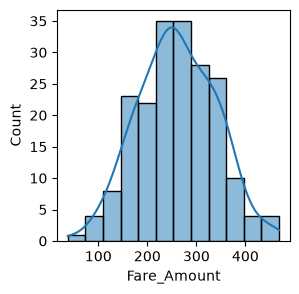

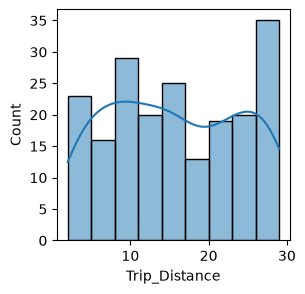

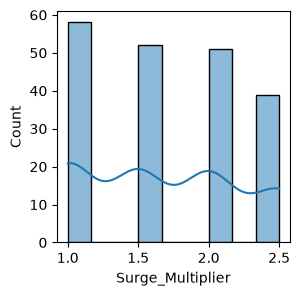

In [141]:
mean_value = df[num_cols].mean()
median_value=df[num_cols].median()
mode_value= df[cat_cols].mode()

print(f"Mean: \n{mean_value}\n")
print(f"Median: \n{median_value}\n")
print(f"Mode: \n{mode_value}\n")

standard_Deviation = df[num_cols].std()
Skewness_value=df[num_cols].skew()
kurtosis_value=df[num_cols].kurtosis()

print(f"standard_Deviation: \n{standard_Deviation}\n")
print(f"Skewness_value: \n{Skewness_value}\n")
print(f"kurtosis_value: \n{kurtosis_value}\n")

variance_value = df[num_cols].var()

print(f"Variance:\n{variance_value}\n")

import seaborn as sns
plt.figure(figsize=(3,3))
sns.histplot(df['Fare_Amount'], kde=True)
plt.show()

plt.figure(figsize=(3,3))
sns.histplot(df['Trip_Distance'], kde=True)
plt.show()

plt.figure(figsize=(3,3))
sns.histplot(df['Surge_Multiplier'], kde=True)
plt.show()

the kurtosis_value are negative , so they are platykurtic
the skew value is approx to 0, they are approximately symmetrical

Correlation

In [142]:
print(df[num_cols].corr(method='pearson'))

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.016813          0.017131   
Fare_Amount            0.016813     1.000000          0.017419   
Surge_Multiplier       0.017131     0.017419          1.000000   
Customer_Rating       -0.084599     0.052723         -0.041304   

                  Customer_Rating  
Trip_Distance           -0.084599  
Fare_Amount              0.052723  
Surge_Multiplier        -0.041304  
Customer_Rating          1.000000  


In [143]:
print(df[num_cols].corr(method='spearman'))


                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.023427          0.025459   
Fare_Amount            0.023427     1.000000          0.011764   
Surge_Multiplier       0.025459     0.011764          1.000000   
Customer_Rating       -0.082067     0.047499         -0.047091   

                  Customer_Rating  
Trip_Distance           -0.082067  
Fare_Amount              0.047499  
Surge_Multiplier        -0.047091  
Customer_Rating          1.000000  


In [144]:
print(df[num_cols].cov())

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance         71.126030    11.160173          0.079296   
Fare_Amount           11.160173  6194.654468          0.752497   
Surge_Multiplier       0.079296     0.752497          0.301250   
Customer_Rating       -1.030352     5.992595         -0.032739   

                  Customer_Rating  
Trip_Distance           -1.030352  
Fare_Amount              5.992595  
Surge_Multiplier        -0.032739  
Customer_Rating          2.085528  


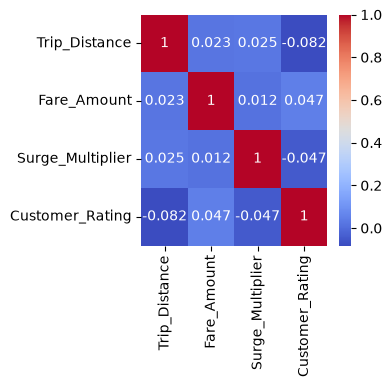

In [145]:
plt.figure(figsize=(3,3))
sns.heatmap(data=df[num_cols].corr(method='spearman'),annot=True,cmap='coolwarm')
plt.show()

Inferential Statistics

In [146]:
population = df['Fare_Amount']

In [147]:
population.mean()

np.float64(260.31237600443757)

In [148]:
sample=np.random.choice(population,size = 100, replace =False)

In [149]:
sample.mean()

np.float64(255.31793700999063)

In [150]:
#poit estimation
point_estimate=sample.mean() #The sample mean is being used as an estimate of the population mean.
point_estimate

np.float64(255.31793700999063)

In [151]:
sample_mean=sample.mean()
sample_std=sample.std(ddof=1)#The ddof=1 is important because it calculates the sample standard deviation rather than the population standard deviation.
n=len(sample)

In [152]:
SE=sample_std/np.sqrt(n)#standard error #How much the sample mean would vary if we repeatedly took samples of size n. as n increases se decrease. more n less SE
sample_lower=sample_mean - 1.96*SE #95% confidence interval = 1.96
sample_upper = sample_mean + 1.96*SE

In [153]:
print(sample_lower,sample_upper)#is the estimate where the true population mean lies.

238.3035260788916 272.33234794108967


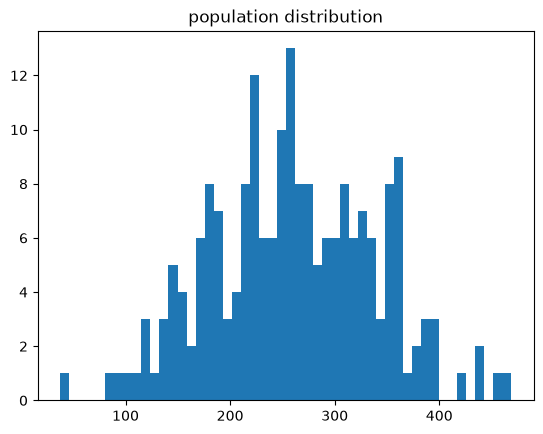

In [154]:
#CLT

import matplotlib.pyplot as plt
plt.hist(population, bins=50)
plt.title("population distribution")
plt.show()

In [155]:
sample_means=[]
for i in range(1000):
    sample=np.random.choice(population, size=30)
    sample_means.append(sample.mean())

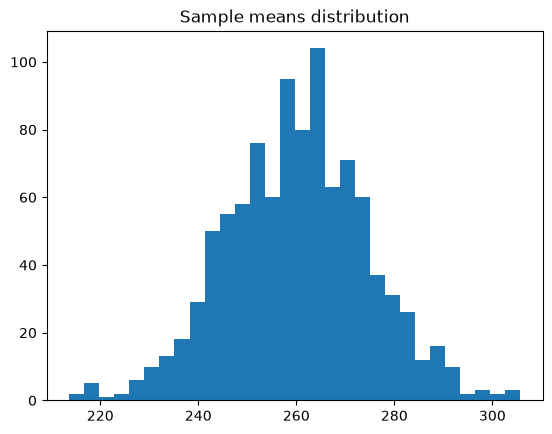

In [157]:
plt.hist(sample_means, bins=30)
plt.title("Sample means distribution")
plt.show()

The CLT is demonstrated by taking 1000 samples of size 30. The shape of population mean was not nomally distributed, the sample mean distribution was approximately normal distribution. This confirms the CLT.

In [158]:
#bootstraping -Repeatedly sampling with replacement from the available data to estimate the sampling distribution of a statistic.
sample_data = np.array(df['Fare_Amount'])
bootstrap_means=[]
for i in range(1000):
    bootstrap_sample=np.random.choice(sample_data,size=len(sample_data),replace=True)
    bootstrap_means.append(bootstrap_sample.mean())


In [159]:
print(bootstrap_means[:5])

[np.float64(260.79848359927365), np.float64(268.51484235908765), np.float64(255.59004990841964), np.float64(255.4063004130312), np.float64(253.69030288785805)]


In [160]:
lower_bootstrap = np.percentile(bootstrap_means, 2.5)
upper_bootstrap = np.percentile(bootstrap_means, 97.5)

print("95% Bootstrap CI:", lower_bootstrap, upper_bootstrap)

95% Bootstrap CI: 248.9572843185668 270.7022623745916


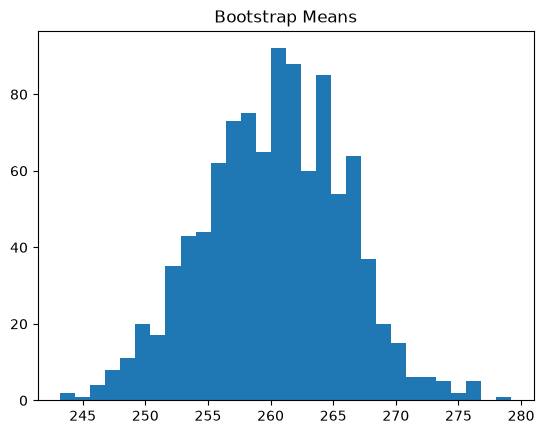

In [161]:
plt.hist(bootstrap_means,bins=30)
plt.title("Bootstrap Means")
plt.show()

In [162]:
np.mean(sample_data)

np.float64(260.31237600443757)

In [163]:
np.mean(bootstrap_means)

np.float64(260.29792881429296)

Hypothesis Testing

In [174]:
peak = df[df['Ride_Time'] == 'Peak']['Fare_Amount']
non_peak = df[df['Ride_Time'] != 'Peak']['Fare_Amount']

z_stat, z_p_value = ztest(peak, non_peak)

print("Z-statistic:", z_stat)
print("p-value:", z_p_value)

if z_p_value < 0.05:
    print("Reject H0: Peak and Non-Peak revenues are significantly different")
else:
    print("Fail to Reject H0: No significant difference in revenue")

Z-statistic: -0.598515832956693
p-value: 0.5494957976214505
Fail to Reject H0: No significant difference in revenue


In [107]:
#one sample t-test

fare_Amount=df['Fare_Amount']
t_stat_1test,p_val_1test = ttest_1samp(fare_Amount,popmean= 270 )
print(t_stat_1test,p_val_1test)

-1.7406991957064 0.08328197352605356


In [108]:
if p_val_1test < 0.05:
    print("Reject null hypothesis")
else:
    print("Failed to Reject the null hypothesis")

Failed to Reject the null hypothesis


In [109]:
#Independant 2 sample t-test
from scipy import stats

group_a = df[df["Ride_Category"] == "Premium"]["Fare_Amount"]
group_b = df[df["Ride_Category"] == "Economy"]["Fare_Amount"]

t_stat_2test, p_value_2test = stats.ttest_ind(group_a, group_b)

print("t-statistic:", t_stat_2test)
print("p-value:", p_value_2test)

t-statistic: -0.4074012822247926
p-value: 0.6843445588292055


In [110]:
if p_value_2test < 0.05:
    print("Premium rides and Economy rides Prices are statistically significant")
else:
    print("Premium rides and Economy rides Prices are not significantly different")

Premium rides and Economy rides Prices are not significantly different


In [166]:
#Chi square test
# Contingency table
table = pd.crosstab(df['Ride_Category'], df['Ride_Time'])

# Chi-square test
chi2, chi_p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("chi_p_value:", chi_p_value)

if chi_p_value < 0.05:
    print("Reject H0: Ride Category and Ride Time are related")
else:
    print("Filed to Reject H0: Ride Category and Ride Time are independent")

Chi-square: 1.4810469877052506
chi_p_value: 0.4768642146833866
Filed to Reject H0: Ride Category and Ride Time are independent


In [125]:
#Anova Testing
# Create groups
economy = df[df['Ride_Category'] == 'Economy']['Fare_Amount']
premium = df[df['Ride_Category'] == 'Premium']['Fare_Amount']

# ANOVA Test
fA_stat, Anova_p_value = f_oneway(economy, premium)

print("F-statistic:", fA_stat)
print("p-value:", Anova_p_value)

if Anova_p_value < 0.05:
    print("Reject H0: Mean fares are significantly different")
else:
    print("Fail to Reject H0: Mean fares are not significantly different")

F-statistic: 0.16597580475840182
p-value: 0.6843445588292086
Fail to Reject H0: Mean fares are not significantly different


Outlier detection

In [ ]:
#percentiles 5th and 95th
data1=df['Fare_Amount']
lower_percentile=np.percentile(data1,1)
print(f"lower bound: {lower_percentile}")  
upper_percentile=np.percentile(data1,99)
print(f"upper bound: {upper_percentile}")  


lower bound: 90.38119158607759
upper bound: 441.2429779984984


In [50]:
filtered_data= data1[(data1>=lower_percentile)&(data1<=upper_percentile)]

In [51]:
outliers_percentile = data1[(data1 < lower_percentile) | (data1 > upper_percentile)]
print(len(outliers_percentile))
print(outliers_percentile)

4
10     37.585916
17     88.214805
63    453.133017
94    468.753773
Name: Fare_Amount, dtype: float64


In [52]:
#using Quartile method
q1=np.percentile(data1,25)
q3=np.percentile(data1,75)
print(q1,q3)

208.5288261048614 319.7637824819526


In [53]:
IQR=q3-q1
IQR

np.float64(111.23495637709121)

In [54]:
lower_bound=q1-1.5*IQR
upper_bound=q3+1.5*IQR

In [55]:
print(lower_bound)
print(upper_bound)

41.67639153922457
486.61621704758943


In [57]:
outliers_iqr = data1[(data1 < lower_bound) | (data1 > upper_bound)]
print(len(outliers_iqr))
print(outliers_iqr)

1
10    37.585916
Name: Fare_Amount, dtype: float64


In [60]:
clean_data=data1[((data1>=lower_bound)&(data1<=upper_bound))]

In [61]:
#Z-score
from scipy.stats import zscore
z=zscore(data1)
#print(z)

In [62]:
outliers_Zscore=data1[abs(z)>=3]
outliers_Zscore
print(len(outliers_Zscore))


0


Basic Probability

In [63]:
#probability of getting a high fare amount 
#the average fare amount is 260 and max is 468. hence im selecting amount 300 above as high fare amount.
high_fare_amt_trip = df['Fare_Amount'][df['Fare_Amount']>=300]

total_trip = df['Fare_Amount']

p_high_fare_amount_trips = high_fare_amt_trip.count() / total_trip.count() 
p_high_fare_amount_trips


np.float64(0.325)

In [167]:
#probability of the ride getting good rating
good_rating_trips =  df['Customer_Rating'][df['Customer_Rating'] >= 4]

total_trips = df['Customer_Rating']

p_good_rating_trips = good_rating_trips.count() / total_trips.count()
p_good_rating_trips

np.float64(0.375)

In [170]:
#probability of the ride being a peak time ride
peak_trips =  df['Ride_Time'][df['Ride_Time'] == 'Peak']

total_trips = df['Ride_Time']

p_peak_time_trip = peak_trips.count() / total_trips.count()
p_peak_time_trip

np.float64(0.515)

In [168]:
#probability of the ride being a surge ride

surge_trips =  df['Surge_Multiplier'][df['Surge_Multiplier']> 1.]

total_trips = df['Surge_Multiplier']

#formula
#p(the trip being a surge trip) = no of surge_trips /total no of trips 

p_surge_trips = surge_trips.count() / total_trips.count() #142/200
p_surge_trips

np.float64(0.71)

In [176]:
#ride category

ride_probs = df['Ride_Category'].value_counts(normalize=True)

print(ride_probs)

Ride_Category
Economy    0.41
Shared     0.30
Premium    0.29
Name: proportion, dtype: float64


Conditional probability

In [172]:
surged_peak = df[(df['Surge_Multiplier']>1.) & (df['Ride_Time'] == 'Peak')]
total_trips=200
p_AnB = len(surged_peak)/total_trips
p_B = p_peak_time_trip # probabiliy of trip being in Peak Time
p_A_given_B = (p_AnB/ p_B)
p_A_given_B

np.float64(0.7184466019417476)

In [ ]:
#event : what is the probability that fare_amount is high given that the ride is in peak hour and Surge is > 1
surge_peak_highfare = len(
    df[(df['Surge_Multiplier']>1.) &
       (df['Ride_Time']=='Peak') &
       (df['Fare_Amount']>=300)]
)

surge_peak = len(
    df[(df['Surge_Multiplier']>1.) &
       (df['Ride_Time']=='Peak')]
)

p_highfare_given_surge_peak = surge_peak_highfare / surge_peak
p_highfare_given_surge_peak

0.28378378378378377

In [177]:
#Probability of a Premium ride given that the trip occurred during Peak hours
peak_trips = df[df['Ride_Time']=='Peak']

p_premium_given_peak = (
    len(peak_trips[peak_trips['Ride_Category']=='Premium'])
    / len(peak_trips)
)

print(p_premium_given_peak)

0.3106796116504854


Bayes Theorem

In [178]:
# P(A) = Probability of Premium ride
p_A = len(df[df['Ride_Category'] == 'Premium']) / len(df)

# P(B) = Probability of Peak ride
p_B = len(df[df['Ride_Time'] == 'Peak']) / len(df)

# P(B|A) = Probability of Peak ride given Premium ride
premium_rides = df[df['Ride_Category'] == 'Premium']
p_B_given_A = len(premium_rides[premium_rides['Ride_Time'] == 'Peak']) / len(premium_rides)

# Bayes Theorem
p_A_given_B = (p_B_given_A * p_A) / p_B

print("P(Premium | Peak) =", p_A_given_B)

P(Premium | Peak) = 0.31067961165048535


Distributions

In [ ]:
normal_mean = df['Fare_Amount'].mean()
normal_std_dev = df['Fare_Amount'].std()
normal_median=df['Fare_Amount'].median()
print(normal_mean)
print(normal_std_dev)
print(normal_median)

260.31237600443757
78.70612725902721
256.90710336367647


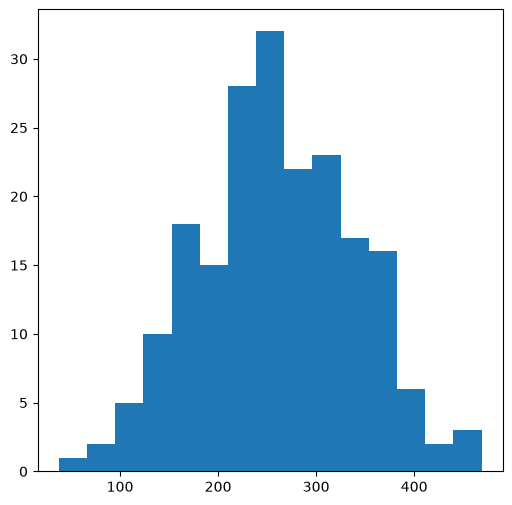

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.hist(x=df['Fare_Amount'],bins=15)
plt.show()

The mean fare amount (260.31) is slightly greater than the median (256), indicating mild positive skewness. The histogram suggests the distribution is approximately bell-shaped with a slight right tail.

In [ ]:
#Binomial Distribution
#probability of getting 3 good ratings out of 5 rides
from math import comb

n=5
k=3
p=p_good_rating_trips
binomial_prob = comb(n, k) * (p ** k) * ((1 - p) ** (n - k))
binomial_prob

Using the Binomial Distribution, the probability of obtaining exactly 3 good ratings in 5 rides was calculated as 0.206 (20.6%). This assumes independent rides and a constant probability of receiving a good rating.